Посмотрим на эффективность multi-head-attention из статьи.

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from pathlib import Path

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
IMAGE_SIZE = 96
NUM_CLASSES = 10
DATA_LIMIT = 50000

DATA_ROOT = Path('./data')
DATA_ROOT.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Data limit: {DATA_LIMIT} images")

Device: cuda
Data limit: 50000 images


In [3]:
from torchvision.datasets import STL10
from torchvision import transforms as T
from torch.utils.data import Subset, random_split


transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

train_full = STL10(root=DATA_ROOT, split='train', transform=transform, download=True)
test_full = STL10(root=DATA_ROOT, split='test', transform=transform, download=True)

TRAIN_SIZE = len(train_full)
TEST_SIZE = len(test_full)

train_dataset = Subset(train_full, range(TRAIN_SIZE))
test_dataset = Subset(test_full, range(TEST_SIZE))


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

100%|██████████| 2.64G/2.64G [01:27<00:00, 30.2MB/s]


Train: 5000 | Test: 8000
Batches per epoch: 157


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def feature_map(x):
    return F.elu(x) + 1.0

class VanillaLinearAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = feature_map(q), feature_map(k), v

        kv = torch.einsum('btd,bte->bde', k, v)
        z = torch.einsum('btd,btd->bt', q, k)
        out = torch.einsum('btd,bde->bte', q, kv)
        return self.out(out / (z.unsqueeze(-1) + 1e-6))

class MHLA(nn.Module):
    def __init__(self, dim, num_blocks=8):
        super().__init__()
        self.dim = dim
        self.num_blocks = num_blocks
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.mix_net = nn.Linear(dim, num_blocks, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = feature_map(q), feature_map(k), v

        pad_len = (self.num_blocks - (T % self.num_blocks)) % self.num_blocks
        if pad_len > 0:
            q_p = F.pad(q, (0, 0, 0, pad_len))
            k_p = F.pad(k, (0, 0, 0, pad_len))
            v_p = F.pad(v, (0, 0, 0, pad_len))
        else:
            q_p, k_p, v_p = q, k, v

        T_pad = q_p.shape[1]
        blk = T_pad // self.num_blocks
        q_b = q_p.reshape(B, self.num_blocks, blk, self.dim)
        k_b = k_p.reshape(B, self.num_blocks, blk, self.dim)
        v_b = v_p.reshape(B, self.num_blocks, blk, self.dim)

        S_m = torch.einsum('bmtd,bmte->bmde', k_b, v_b)
        z_m = k_b.sum(dim=2)  # (B, M, D)

        w = F.softmax(self.mix_net(q), dim=-1)  # (B, T, M)

        S_tilde = torch.einsum('btm,bmde->btde', w, S_m)  # (B, T, D, D)
        z_tilde = torch.einsum('btm,bmd->btd', w, z_m)    # (B, T, D)

        out = torch.einsum('btd,btde->bte', q, S_tilde)   # (B, T, D)
        denom = torch.einsum('btd,btd->bt', q, z_tilde)   # (B, T)
        return self.out(out / (denom.unsqueeze(-1) + 1e-6))

In [10]:
class PatchAttentionClassifier(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, embed_dim=64, patch_size=12, num_blocks=4, attention_type='mhla'):
        super().__init__()
        assert IMAGE_SIZE % patch_size == 0, "patch_size must divide IMAGE_SIZE"
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.attention_type = attention_type

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.GELU()
        )

        if attention_type == 'vanilla':
            self.attn = VanillaLinearAttention(embed_dim)
        elif attention_type == 'mhla':
            self.attn = MHLA(embed_dim, num_blocks=num_blocks)
        else:
            raise ValueError(f"Unknown attention type: {attention_type}")


        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        # Stem: (B, C, H, W) -> (B, D, Ph, Pw)
        x = self.stem(x)
        B, D, Ph, Pw = x.shape
        # Flatten to sequence: (B, T, D), T = Ph * Pw
        x = x.permute(0, 2, 3, 1).reshape(B, -1, D)
        # Attention
        x = self.attn(x)
        # Global average pooling over tokens
        x = x.mean(dim=1)
        return self.head(x)

In [12]:
import copy
import torch
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def run_experiment(attention_type, num_blocks=4, epochs=EPOCHS, lr=LR, device=DEVICE):
    print(f"--- Training {attention_type.upper()} ---")
    model = PatchAttentionClassifier(
        in_channels=3, num_classes=NUM_CLASSES, embed_dim=64,
        patch_size=12, num_blocks=num_blocks, attention_type=attention_type
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_acc': [], 'val_loss': []}
    best_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_acc:
            best_acc = v_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f"Ep {epoch:02d}/{epochs} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_acc

In [15]:
results = {}
EPOCHS_RUN = 100

model_v, hist_v, best_v = run_experiment('vanilla', num_blocks=4, epochs=EPOCHS_RUN)
results['vanilla'] = {'history': hist_v, 'best_acc': best_v}

model_m, hist_m, best_m = run_experiment('mhla', num_blocks=4, epochs=EPOCHS_RUN)
results['mhla'] = {'history': hist_m, 'best_acc': best_m}

print("\n--- СВОДКА ---")
print(f"Vanilla Best Acc: {best_v:.4f}")
print(f"MHLA    Best Acc: {best_m:.4f}")
print(f"Delta (MHLA - Vanilla): {(best_m - best_v):+.4f}")

=== Запуск VANILLA Linear Attention ===
--- Training VANILLA ---
Ep 01/100 | Train Loss: 1.9424 | Val Loss: 1.8357 | Val Acc: 0.3099
Ep 05/100 | Train Loss: 1.6680 | Val Loss: 1.7136 | Val Acc: 0.3475
Ep 10/100 | Train Loss: 1.5525 | Val Loss: 1.6792 | Val Acc: 0.3493
Ep 15/100 | Train Loss: 1.4670 | Val Loss: 1.5954 | Val Acc: 0.3991
Ep 20/100 | Train Loss: 1.4070 | Val Loss: 1.5626 | Val Acc: 0.4131
Ep 25/100 | Train Loss: 1.3481 | Val Loss: 1.5374 | Val Acc: 0.4325
Ep 30/100 | Train Loss: 1.2843 | Val Loss: 1.5660 | Val Acc: 0.4313
Ep 35/100 | Train Loss: 1.2352 | Val Loss: 1.5915 | Val Acc: 0.4283
Ep 40/100 | Train Loss: 1.1653 | Val Loss: 1.6078 | Val Acc: 0.4305
Ep 45/100 | Train Loss: 1.1243 | Val Loss: 1.6837 | Val Acc: 0.4301
Ep 50/100 | Train Loss: 1.0498 | Val Loss: 1.8542 | Val Acc: 0.4004
Ep 55/100 | Train Loss: 0.9981 | Val Loss: 1.8369 | Val Acc: 0.4006
Ep 60/100 | Train Loss: 0.9328 | Val Loss: 1.8716 | Val Acc: 0.4104
Ep 65/100 | Train Loss: 0.8558 | Val Loss: 1.9521 |

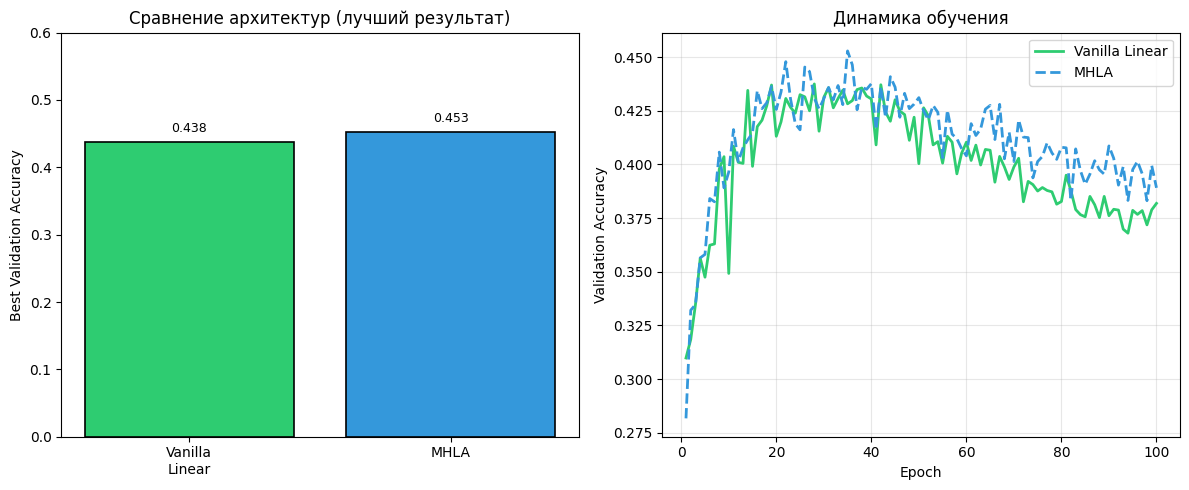

Метрика                   Vanilla Linear  MHLA           
-------------------------------------------------------
Best Accuracy             0.4375        0.4529
Final Accuracy            0.3819        0.3891
Final Train Loss          0.5473        0.5091
Params Count              44938        45194


In [16]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, EPOCHS_RUN + 1)
hist_v = results['vanilla']['history']
hist_m = results['mhla']['history']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
models = ['Vanilla\nLinear', 'MHLA']
best_accs = [results['vanilla']['best_acc'], results['mhla']['best_acc']]
colors = ['#2ecc71', '#3498db']
bars = plt.bar(models, best_accs, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('Best Validation Accuracy')
plt.title('Сравнение архитектур (лучший результат)')
plt.ylim(0, 0.6)
for bar, acc in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)


plt.subplot(1, 2, 2)
plt.plot(epochs, hist_v['val_acc'], label='Vanilla Linear', color=colors[0], linewidth=2)
plt.plot(epochs, hist_m['val_acc'], label='MHLA', color=colors[1], linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Динамика обучения')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print(f"{'Метрика':<25} {'Vanilla Linear':<15} {'MHLA':<15}")
print("-" * 55)
print(f"{'Best Accuracy':<25} {results['vanilla']['best_acc']:.4f}        {results['mhla']['best_acc']:.4f}")
print(f"{'Final Accuracy':<25} {hist_v['val_acc'][-1]:.4f}        {hist_m['val_acc'][-1]:.4f}")
print(f"{'Final Train Loss':<25} {hist_v['train_loss'][-1]:.4f}        {hist_m['train_loss'][-1]:.4f}")
print(f"{'Params Count':<25} {44938}        {45194}")

In [17]:
"""ВЫВОД
MHLA - Показал себя совсем чуть чуть лучше, чем классический механизм внимания.
 Однако я считаю что тут сыграли на руки данные, если бы чуть посложнее была бы задача, то отрыв был более очевидным.
 Для этого последоватьельность патчей бы побольше
"""

'ВЫВОД\nMHLA - Показал себя совсем чуть чуть лучше, чем классический механизм внимания.\n Однако я считаю что тут сыграли на руки данные, если бы чуть посложнее была бы задача, то отрыв был более очевидным. \n Для этого последоватьельность патчей бы побольше\n'